# spotWithAnnularContrastReversingGrating — reversing annular grating

The reversing sibling of `analyze_flash_grate.ipynb`, with the same structure — discover, group,
keep the canonical conditions, schematic, analyze, store, population figure — and sharing that
notebook's helpers for light level, the cone model and the grouping logic.

**The stimulus** is the same annular square-wave grating, now reversing at
`currentTemporalFrequency`. Two details from
`chris-package/.../spotWithAnnularContrastReversingGrating.m` matter:

* The protocol's comment describes a sinusoid, but `getGratingFrame` applies
  `sign(cos(2·pi·f·t))` — the reversal is a **square wave** alternating between two fixed frames.
* The frames are asymmetric: with `Ap = brightBarContrast` and `An = |darkBarContrast|`, one
  frame puts the bright-bar set at `-An` and the dark set at `+Ap`, the other swaps them. At
  onset `sign(cos 0) = +1` selects the inverted frame, called **phase A** here.

**This protocol does not measure the flashed protocol's cancellation null.** At every instant
half the bars sit at `+Ap` and half at `-An` — reversing swaps *which* bars, not the set of
intensities on screen. A receptive field centred on the grating therefore gets the same drive in
both half cycles, so the bright/dark balance has nothing to null. (In the flashed version the two
bar sets are presented simultaneously and summed, which is what makes them cancel.) What the
reversal modulates is the spatial arrangement, and rectifying subunits turn that into a
frequency-doubled response.

So the measurement here is a **contrast-response function**: F1 and F2 amplitude versus
dark-bar contrast. The half-cycle difference is kept as a check on the symmetry argument — it
should sit at zero, and a large value means the grating was not centred on the cell.

In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import spot_annular_crg as crg

## 1. Find every block that ran the protocol

Same columns as the flashed notebook plus `temporalFrequency` and `barWidth`, both constant
within a block. Light level is `background:FilterWheel:NDF` plus `backgroundIntensity`, and
uncalibrated combinations keep `rstar = NaN` rather than being estimated — attach your own
conversion with `crg.apply_rstar_mapping` when you have it.

In [2]:
df_blocks = crg.find_blocks()

35 blocks | 5 experiments | 12 cells


exp_name,cell_label,cell_type_short,onlineAnalysis,grating_site,temporalFrequency,barWidth,filter_wheel_ndf,backgroundIntensity,light_level,annulusInnerDiameter,annulusOuterDiameter,stimTime,n_epochs,block_id
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,22,34330
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,150.0,1.0,0.5,FW1/bg0.5 (?R*),0.0,500.0,4000.0,22,34333
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,14,34334
2026-04-23_E,Cell2,OFF-parasol,extracellular,center,4.0,75.0,1.0,0.5,FW1/bg0.5 (?R*),0.0,500.0,4000.0,11,34324
2026-04-23_E,Cell2,OFF-parasol,extracellular,center,4.0,75.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,12,34325
2026-04-23_E,Cell3,horizontal,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,14,34315
2026-04-23_E,Cell3,horizontal,extracellular,center,4.0,150.0,1.0,0.5,FW1/bg0.5 (?R*),0.0,500.0,4000.0,22,34317
2026-04-23_E,Cell4,horizontal,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,12,34305
2026-04-23_E,Cell4,horizontal,extracellular,center,4.0,150.0,1.0,0.5,FW1/bg0.5 (?R*),0.0,500.0,4000.0,22,34306
2026-04-23_E,Cell4,horizontal,extracellular,center,4.0,150.0,0.0,0.5,FW0/bg0.5 (?R*),0.0,500.0,4000.0,22,34309


## 2. Group, then keep the canonical conditions

A group is experiment × cell × recording mode × grating site × **temporal frequency** ×
filter wheel × background. Temporal frequency is a grouping key here because it changes the
response; bar width is pooled, as in the flashed analysis.

In [3]:
groups = crg.group_blocks(df_blocks)
canonical = crg.select_canonical(groups)

28 recording groups (experiment x cell x mode x grating site x temporal frequency x filter wheel x background)


exp_name,cell_label,cell_type_short,onlineAnalysis,grating_site,temporalFrequency,filter_wheel_ndf,backgroundIntensity,blocks,epochs,light_level,rstar,light_setting,rstar_measured,bar_widths,block_ids
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,0.0,0.5,2,36,FW0/bg0.5 (?R*),,FW0/bg0.5,False,150,"34330, 34334"
,,,extracellular,center,4.0,1.0,0.5,1,22,FW1/bg0.5 (?R*),,FW1/bg0.5,False,150,34333
,Cell2,,extracellular,center,4.0,1.0,0.5,1,11,FW1/bg0.5 (?R*),,FW1/bg0.5,False,75,34324
,,,extracellular,center,4.0,0.0,0.5,1,12,FW0/bg0.5 (?R*),,FW0/bg0.5,False,75,34325
,Cell6,,extracellular,center,4.0,0.0,0.5,2,25,FW0/bg0.5 (?R*),,FW0/bg0.5,False,100,"34291, 34295"
,,,extracellular,center,4.0,1.0,0.5,1,22,FW1/bg0.5 (?R*),,FW1/bg0.5,False,100,34294
2026-04-24_E,Cell2,,extracellular,center,4.0,1.0,0.5,1,22,FW1/bg0.5 (?R*),,FW1/bg0.5,False,50,34360
,,,extracellular,center,4.0,0.0,0.5,1,22,FW0/bg0.5 (?R*),,FW0/bg0.5,False,50,34361
2026-06-04_G,Cell2,,extracellular,center,2.0,0.5,0.15,1,21,4000R*,4000.0,FW0.5/bg0.15,True,80,35031
,,,extracellular,center,2.0,0.0,0.15,1,21,12000R*,12000.0,FW0/bg0.15,True,80,35032


17 of 28 groups are ON-parasol/surround or OFF-parasol/center
onlineAnalysis         extracellular
condition                           
OFF-parasol / center              15
ON-parasol / surround              2
  with a measured light level: 7; with any light level: 7


In [4]:
print('cell type x grating site (blocks)')
display(pd.crosstab(df_blocks['cell_type_short'], df_blocks['grating_site']))

print('\ncell type x recording mode (blocks)')
display(pd.crosstab(df_blocks['cell_type_short'], df_blocks['onlineAnalysis']))

cell type x grating site (blocks)


grating_site,center,surround
cell_type_short,,
OFF-parasol,18,0
ON-parasol,7,4
bipolar,1,0
horizontal,5,0



cell type x recording mode (blocks)


onlineAnalysis,exc,extracellular
cell_type_short,,
OFF-parasol,0,18
ON-parasol,0,11
bipolar,1,0
horizontal,0,5


Two things to note in those tables, both limits of the dataset rather than the code:

* **There is no whole-cell parasol data for this protocol.** The single `exc` block is a bipolar
  cell, so the `exc` panels below are empty.
* Most ON-parasol recordings put the grating over the **center**, the non-canonical pairing, so
  only a couple of ON-parasol/surround groups survive `select_canonical`.

## 3. Stimulus schematic

The two half-cycle frames and the square wave they alternate on. Phase A is what appears at
stimulus onset.

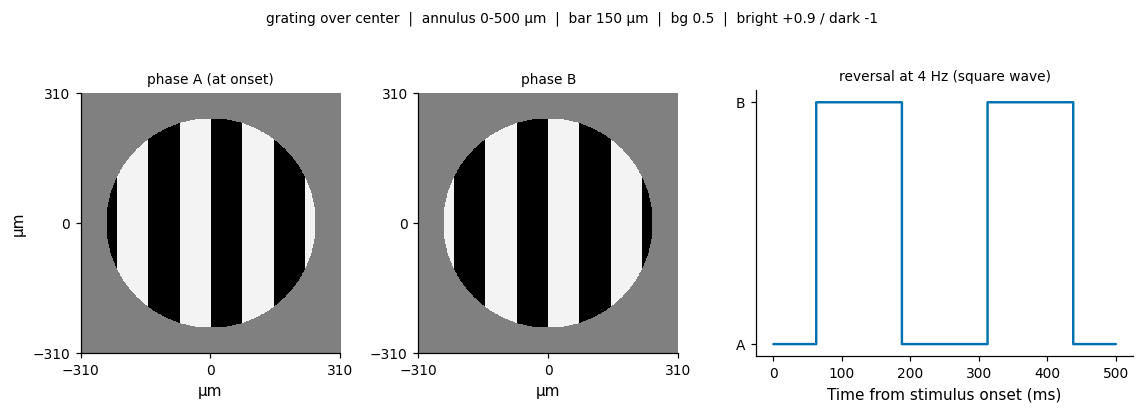

In [5]:
def block_params(block_id):
    exp = df_blocks.loc[df_blocks.block_id.eq(block_id), 'exp_name'].iloc[0]
    return ra.StimBlock(exp, int(block_id), verbose=False).df_epochs['epoch_parameters'].iloc[0]

first_block = int(canonical.block_ids.iloc[0].split(',')[0])
crg.plot_stimulus_schematic(block_params(first_block));

## 4. Analyze one recording group

Per epoch the stimulus window is folded into reversal cycles (dropping the first, which carries
the onset transient), then F1 and F2 amplitudes are measured on that window.

Top: the mean reversal cycle per dark contrast — two response bursts per cycle, one at each
reversal, which *is* the frequency doubling. Middle: the contrast-response function. Bottom: the
half-cycle difference, the symmetry check.

If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Max trial length in data points: 10000 = 1 s
Trial 1: Found 10275 peaks


Trial 1: Splitting data into 5 sections for KMeans clustering.


Trial 1: Found 93 spikes
Trial 2: Found 10319 peaks


Trial 2: Splitting data into 5 sections for KMeans clustering.
Trial 2: Found 85 spikes
Trial 3: Found 10237 peaks


...

Trial 9: Splitting data into 5 sections for KMeans clustering.
Trial 9: Found 83 spikes
Trial 10: Found 9078 peaks


Trial 10: Splitting data into 5 sections for KMeans clustering.
Trial 10: Found 86 spikes
Trial 11: Found 9008 peaks


Trial 11: Splitting data into 5 sections for KMeans clustering.
Trial 11: Found 83 spikes
Trial 12: Found 9144 peaks


Trial 12: Splitting data into 5 sections for KMeans clustering.
Trial 12: Found 87 spikes


2026-04-23_E | RGC\ON-parasol | Cell5 | extracellular | grating surround | 4 Hz | FW=0.0 bg=0.50 (FW0/bg0.5 (?R*)) | 50 epochs
  dark contrasts   : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  phase A - B      : [ 1.804 -0.904 -1.038 -2.318 -2.127  0.11   0.479 -0.936 -2.324  0.413
 -1.771]
  F1 / F2          : [9.22 6.3  6.71 5.98 5.6  3.   3.48 2.59 3.03 1.53 2.72] / [14.76 15.55 14.59 14.51 13.29 13.52 12.54 10.9   8.26  8.32  6.27]
  null nearest=-0.500 interp=-0.933 | cone pred=nan


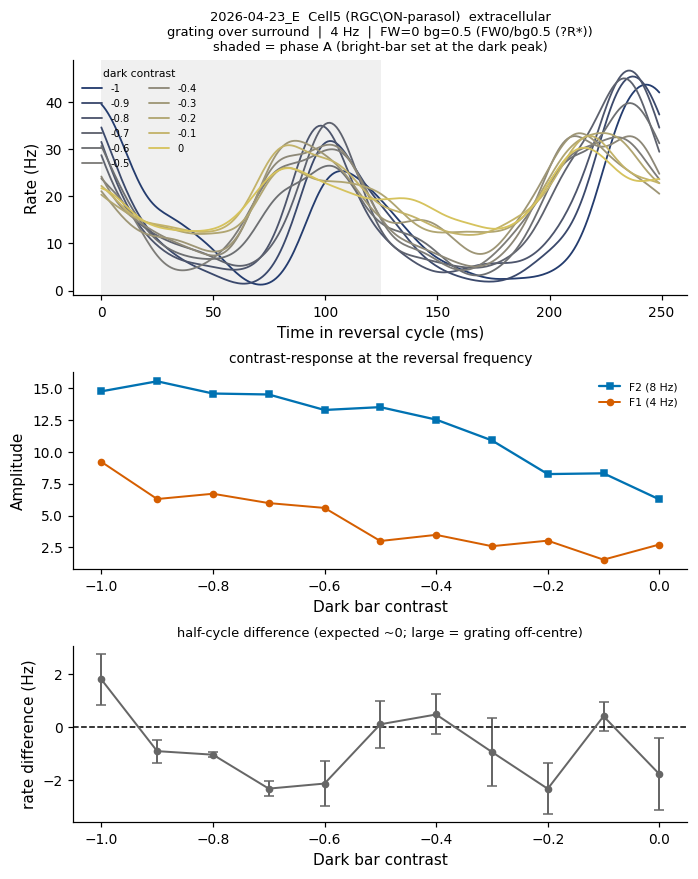

In [6]:
row = canonical.sort_values('epochs', ascending=False).iloc[0]
rec = crg.analyze_group(row.exp_name, [int(b) for b in row.block_ids.split(',')],
                        online_analysis=row.onlineAnalysis)
crg.plot_group(rec);

## 5. Batch analyze and save

Records go to `<OUTPUT_DIR>/spot_annular_crg/records.h5` with a `summary.csv` index, upserted per
(experiment, cell, mode, grating site, temporal frequency, filter wheel, background) — the same
layout as the flashed protocol, in its own directory.

In [7]:
records = crg.analyze_all(canonical, save=True, plot=False, skip_existing=True)

analyzed 0/17 groups (17 already stored, skipped)


## 6. Population contrast-response

One panel per condition × recording mode, one line per recording, coloured by light setting.
This replaces the flashed notebook's crossing-vs-Weber figure, which does not apply here.

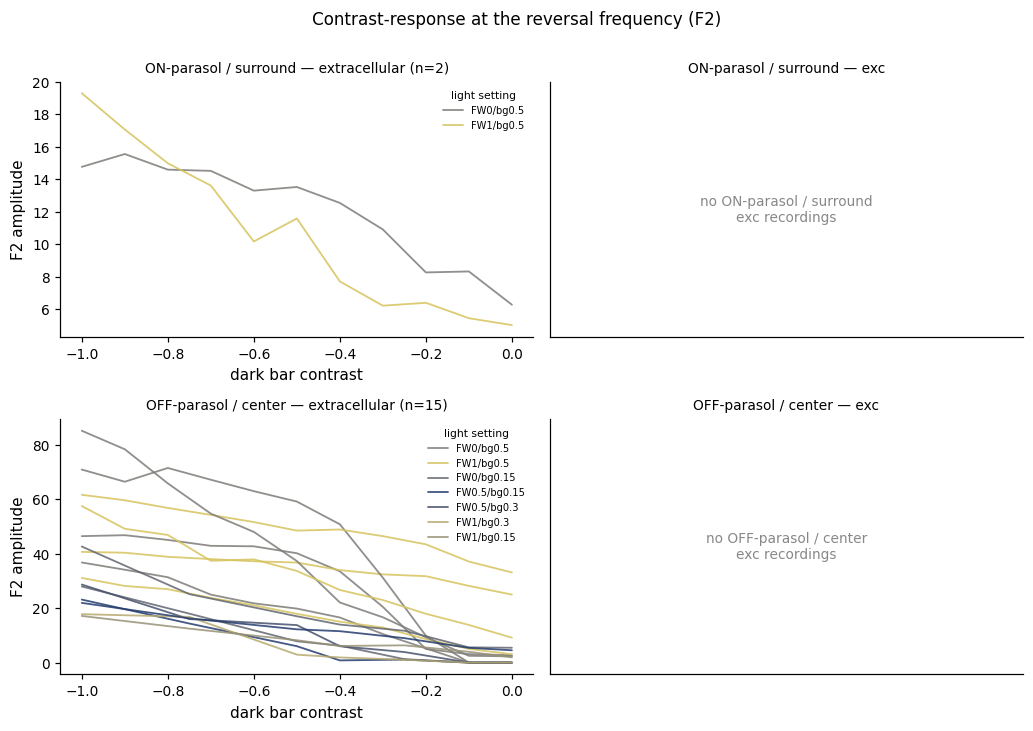

In [8]:
crg.plot_contrast_response();

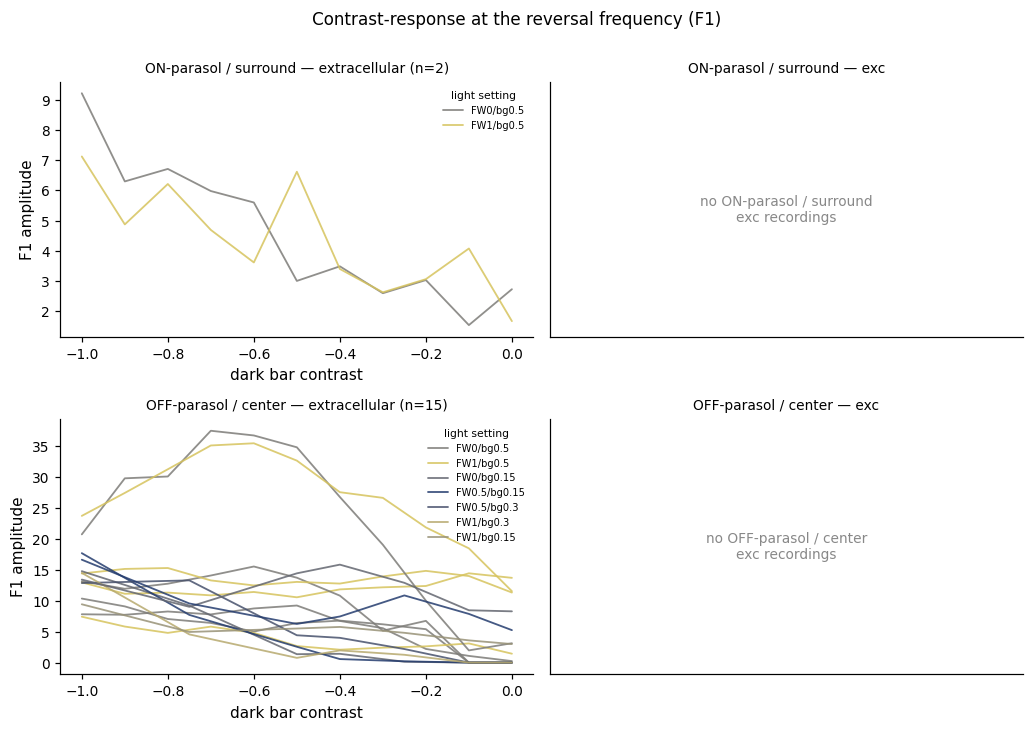

In [9]:
# F1 for the same recordings: much smaller than F2 throughout, which is the
# signature of a frequency-doubling response to a reversing grating.
crg.plot_contrast_response(harmonic='f1_mean');

### Is there any balance point hiding in these curves?

If the bright/dark balance mattered, a harmonic would dip at some intermediate contrast. It does
not: F2 rises monotonically with dark-bar contrast in every recording. The correlation of F2 with
|dark contrast| is computed per record below.

In [10]:
rows = []
for key, r in crg.load_records().items():
    x = np.abs(r['dark_contrasts'])
    rows.append({'cell': f"{r['exp_name']} {r['cell_label']}",
                 'mode': r['online_analysis'], 'Hz': float(r['temporal_frequency']),
                 'light': r['light_setting'],
                 'corr(|dark|, F1)': np.corrcoef(x, r['f1_mean'])[0, 1],
                 'corr(|dark|, F2)': np.corrcoef(x, r['f2_mean'])[0, 1],
                 'median F2/F1': float(np.median(r['f2_mean'] / np.maximum(r['f1_mean'], 1e-9)))})
mono = pd.DataFrame(rows).round(2)
print(f"F2 rises with contrast in {int((mono['corr(|dark|, F2)'] > 0.9).sum())}/{len(mono)} "
      f"recordings (correlation > 0.9)")
sc.scroll_table(mono, height=300)

F2 rises with contrast in 17/17 recordings (correlation > 0.9)


cell,mode,Hz,light,"corr(|dark|, F1)","corr(|dark|, F2)",median F2/F1
2026-04-23_E Cell1,extracellular,4.0,FW0/bg0.5,0.83,0.93,4.97
2026-04-23_E Cell1,extracellular,4.0,FW1/bg0.5,-0.57,0.97,3.13
2026-04-23_E Cell2,extracellular,4.0,FW0/bg0.5,0.83,0.93,4.69
2026-04-23_E Cell2,extracellular,4.0,FW1/bg0.5,0.49,0.98,3.71
2026-04-23_E Cell5,extracellular,4.0,FW0/bg0.5,0.92,0.94,2.47
2026-04-23_E Cell5,extracellular,4.0,FW1/bg0.5,0.77,0.97,2.41
2026-04-23_E Cell6,extracellular,4.0,FW0/bg0.5,0.86,0.99,3.1
2026-04-23_E Cell6,extracellular,4.0,FW1/bg0.5,0.89,1.0,4.36
2026-04-24_E Cell2,extracellular,4.0,FW0/bg0.5,0.71,0.99,1.26
2026-04-24_E Cell2,extracellular,4.0,FW1/bg0.5,0.62,0.99,1.03


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:300px"><table><thead><tr><th>cell</th><th>mode</th><th>Hz</th><th>light</th><th>corr(|dark|, F1)</th><th>corr(|dark|, F2)</th><th>median F2/F1</th></tr></thead><tbody><tr><td>2026-04-23_E Cell1</td><td>extracellular</td><td>4.0</td><td>FW0/bg0.5<

## 7. Come back later

`load_summary()` reads the scalar index without touching DataJoint or the SSD; `load_records()`
pulls the arrays. `crg.plot_condition_examples()` also works, but note its tuning panel shows the
half-cycle difference — the symmetry check — not the contrast-response.

In [11]:
summary = crg.add_condition(crg.load_summary())
sc.scroll_table(summary[['exp_name', 'cell_label', 'cell_type_short', 'online_analysis',
                         'grating_site', 'temporal_frequency', 'light_setting',
                         'f1_max', 'f2_max', 'n_epochs']], height=320)

exp_name,cell_label,cell_type_short,online_analysis,grating_site,temporal_frequency,light_setting,f1_max,f2_max,n_epochs
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,FW0/bg0.5,9.2397369464734,46.80062987197675,36
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,4.0,FW1/bg0.5,14.456656185414014,40.66824831043698,22
2026-04-23_E,Cell2,OFF-parasol,extracellular,center,4.0,FW0/bg0.5,15.55697787411701,71.49097730083882,12
2026-04-23_E,Cell2,OFF-parasol,extracellular,center,4.0,FW1/bg0.5,15.310712654323886,61.63275946659227,11
2026-04-23_E,Cell6,OFF-parasol,extracellular,center,4.0,FW0/bg0.5,10.367062141366173,36.77063547594333,25
2026-04-23_E,Cell6,OFF-parasol,extracellular,center,4.0,FW1/bg0.5,7.431352706687701,31.096667951593,22
2026-04-24_E,Cell2,OFF-parasol,extracellular,center,4.0,FW0/bg0.5,37.5304495619578,85.16166784707362,22
2026-04-24_E,Cell2,OFF-parasol,extracellular,center,4.0,FW1/bg0.5,35.5038384813849,57.50783357931,22
2026-06-04_G,Cell2,OFF-parasol,extracellular,center,2.0,FW0/bg0.15,14.798481845422295,27.955226038945046,21
2026-06-04_G,Cell2,OFF-parasol,extracellular,center,2.0,FW0.5/bg0.15,17.713975540364476,23.144278843424292,21


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:320px"><table><thead><tr><th>exp_name</th><th>cell_label</th><th>cell_type_short</th><th>online_analysis</th><th>grating_site</th><th>temporal_frequency</th><th>light_setting</th><th>f1_max</th><th>f2_max</th><th>n_epochs</th></tr></thead><tbody>

## Inspect one cell

Everything above runs across the whole dataset. This section goes the other way: name a single
cell and see every recording of it, split by condition.

A cell is identified by `'<experiment>/<cell label>'`, e.g. `'2026-06-04_G/Cell2'`. `list_cells` shows the
available ids together with the conditions each cell was recorded in — recording mode, site,
light setting, and whatever else varies for this protocol — so you can pick one. A bare cell
label also works when it is unambiguous.

In [12]:
crg.list_cells(canonical)

7 cells, 17 recording conditions in total


cell_id,cell_type,conditions,epochs,onlineAnalysis,grating_site,temporalFrequency,bar_widths,light_setting,light_level,filter_wheel_ndf,backgroundIntensity
2026-04-23_E/Cell1,OFF-parasol,2,58,extracellular,center,4.0,150,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-23_E/Cell2,,2,23,extracellular,center,4.0,75,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-23_E/Cell6,,2,47,extracellular,center,4.0,100,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-24_E/Cell2,,2,44,extracellular,center,4.0,50,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-06-04_G/Cell2,,4,84,extracellular,center,2.0,80,"FW0.5/bg0.15, FW0.5/bg0.3, FW0/bg0.15, FW1/bg0.3","12000R*, 2000R*, 4000R*, 8000R*","0.0, 0.5, 1.0","0.15, 0.3"
2026-06-04_G/Cell3,,3,71,extracellular,center,2.0,80,"FW0.5/bg0.15, FW0/bg0.15, FW1/bg0.15","1000R*, 12000R*, 4000R*","0.0, 0.5, 1.0",0.15
2026-04-23_E/Cell5,ON-parasol,2,72,extracellular,surround,4.0,100,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5


,cell_id,cell_type,conditions,epochs,onlineAnalysis,grating_site,temporalFrequency,bar_widths,light_setting,light_level,filter_wheel_ndf,backgroundIntensity
0,2026-04-23_E/Cell1,OFF-parasol,2,58,extracellular,center,4.0,150,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
1,2026-04-23_E/Cell2,OFF-parasol,2,23,extracellular,center,4.0,75,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2,2026-04-23_E/Cell6,OFF-parasol,2,47,extracellular,center,4.0,100,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
3,2026-04-24_E/Cell2,OFF-parasol,2,44,extracellular,center,4.0,50,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
4,2026-06-04_G/Cell2,OFF-parasol,4,84,extracellular,center,2.0,80,"FW0.5/bg0.15, FW0.5/bg0.3, FW0/bg0.15, FW1/bg0.3","12000R*, 2000R*, 4000R*, 8000R*","0.0, 0.5, 1.0","0.15, 0.3"
5,2026-06-04_G/Cell3,OFF-parasol,3,71,extracellular,center,2.0,80,"FW0.5/bg0.15, FW0/bg0.15, FW1/bg0.15","1000R*, 12000R*, 4000R*","0.0, 0.5, 1.0",0.15
6,2026-04-23_E/Cell5,ON-parasol,2,72,extracellular,surround,4.0,100,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5


2026-06-04_G/Cell2: 4 recording condition(s), 84 epochs, cell type OFF-parasol


onlineAnalysis,grating_site,temporalFrequency,bar_widths,light_setting,light_level,filter_wheel_ndf,backgroundIntensity,blocks,epochs,block_ids
extracellular,center,2.0,80,FW0.5/bg0.15,4000R*,0.5,0.15,1,21,35031
extracellular,center,2.0,80,FW0/bg0.15,12000R*,0.0,0.15,1,21,35032
extracellular,center,2.0,80,FW1/bg0.3,2000R*,1.0,0.3,1,21,35033
extracellular,center,2.0,80,FW0.5/bg0.3,8000R*,0.5,0.3,1,21,35034


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Max trial length in data points: 10000 = 1 s
Trial 1: Found 3427 peaks
Trial 1: Splitting data into 2 sections for KMeans clustering.
Trial 1: Found 847 spikes
Trial 1: no spikes!
Trial 2: Found 3463 peaks
Trial 2: Splitting data into 2 sections for KMeans clustering.
Trial 2: Found 892 spikes
Trial 2: no spikes!
Trial 3: Found 3423 peaks


Trial 3: Splitting data into 2 sections for KMeans clustering.
Trial 3: Found 1573 spikes
Trial 3: no spikes!
Trial 4: Found 3369 peaks
Trial 4: Splitting data into 2 sections for KMeans clustering.
Trial 4: Found 840 spikes
Trial 4: no spikes!
Trial 5: Found 3393 peaks
Trial 5: Splitting data into 2 sections for KMeans clustering.


...

Trial 11: Splitting data into 2 sections for KMeans clustering.
Trial 11: Found 2 spikes
Trial 12: Found 3336 peaks
Trial 12: Splitting data into 2 sections for KMeans clustering.
Trial 12: Found 8 spikes
Trial 13: Found 3322 peaks
Trial 13: Splitting data into 2 sections for KMeans clustering.
Trial 13: Found 18 spikes
Trial 14: Found 3280 peaks


Trial 14: Splitting data into 2 sections for KMeans clustering.
Trial 14: Found 30 spikes
Trial 15: Found 3364 peaks
Trial 15: Splitting data into 2 sections for KMeans clustering.
Trial 15: Found 777 spikes
Trial 15: no spikes!
Trial 16: Found 3408 peaks
Trial 16: Splitting data into 2 sections for KMeans clustering.


Trial 16: Found 779 spikes
Trial 16: no spikes!
Trial 17: Found 3374 peaks
Trial 17: Splitting data into 2 sections for KMeans clustering.
Trial 17: Found 3 spikes
Trial 18: Found 3381 peaks
Trial 18: Splitting data into 2 sections for KMeans clustering.
Trial 18: Found 5 spikes
Trial 19: Found 3365 peaks


Trial 19: Splitting data into 2 sections for KMeans clustering.
Trial 19: Found 7 spikes
Trial 20: Found 3331 peaks
Trial 20: Splitting data into 2 sections for KMeans clustering.
Trial 20: Found 19 spikes
Trial 21: Found 3295 peaks
Trial 21: Splitting data into 2 sections for KMeans clustering.
Trial 21: Found 32 spikes


2026-06-04_G | RGC\OFF-parasol | Cell2 | extracellular | grating center | 2 Hz | FW=0.5 bg=0.30 (8000R*) | 21 epochs
  dark contrasts   : [-1.   -0.75 -0.5  -0.4  -0.25 -0.1   0.  ]
  phase A - B      : [ 2.291  5.427 -2.643  4.067 -1.767  0.     0.   ]
  F1 / F2          : [12.88 13.31  4.43  4.01  2.2   0.    0.  ] / [28.67 15.99 13.78  6.01  3.89  0.    0.  ]
  null nearest=-0.100 interp=-0.582 | cone pred=-0.369
analyzed 4/4 conditions for 2026-06-04_G/Cell2


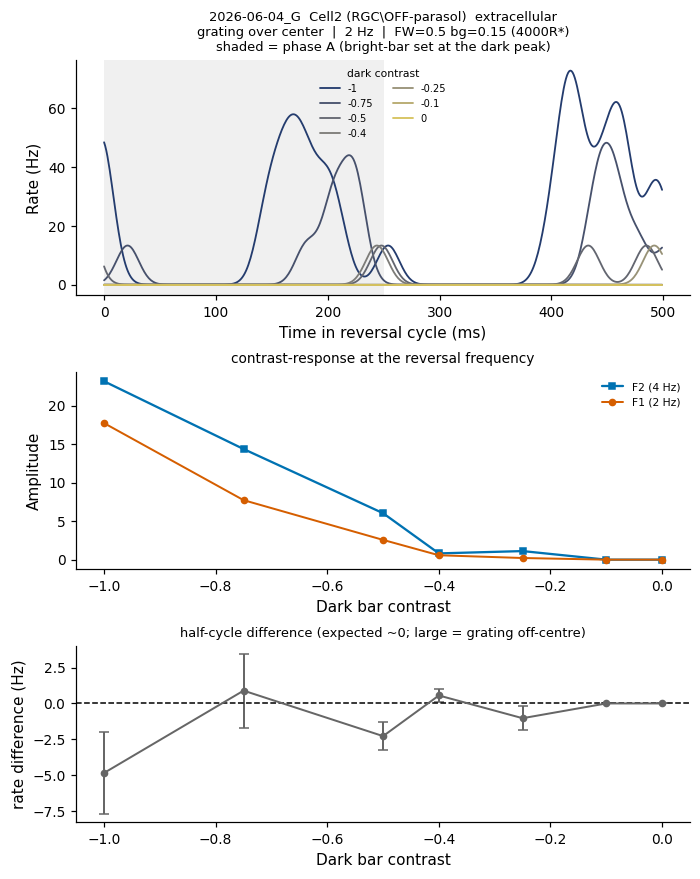

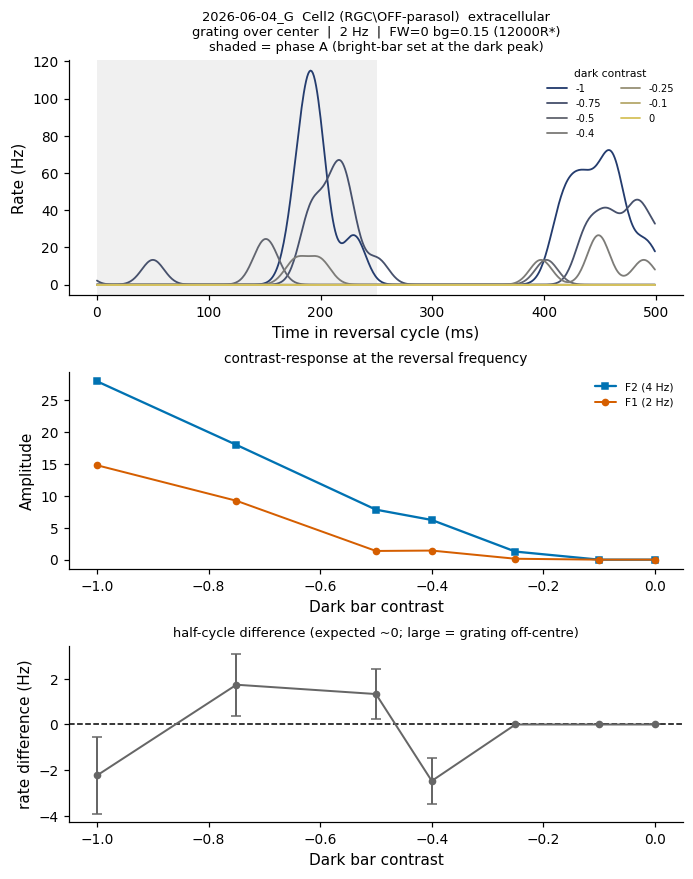

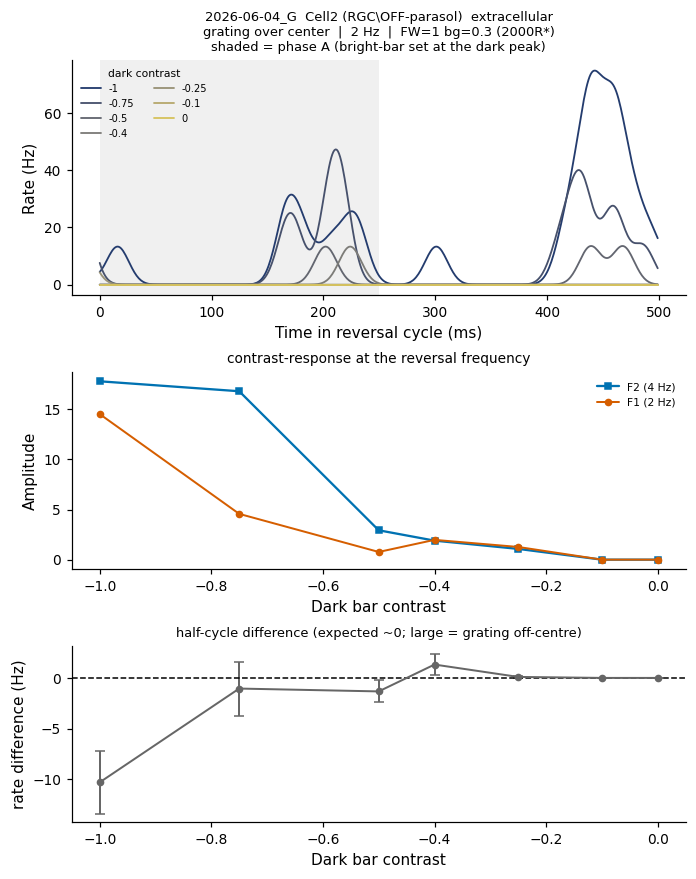

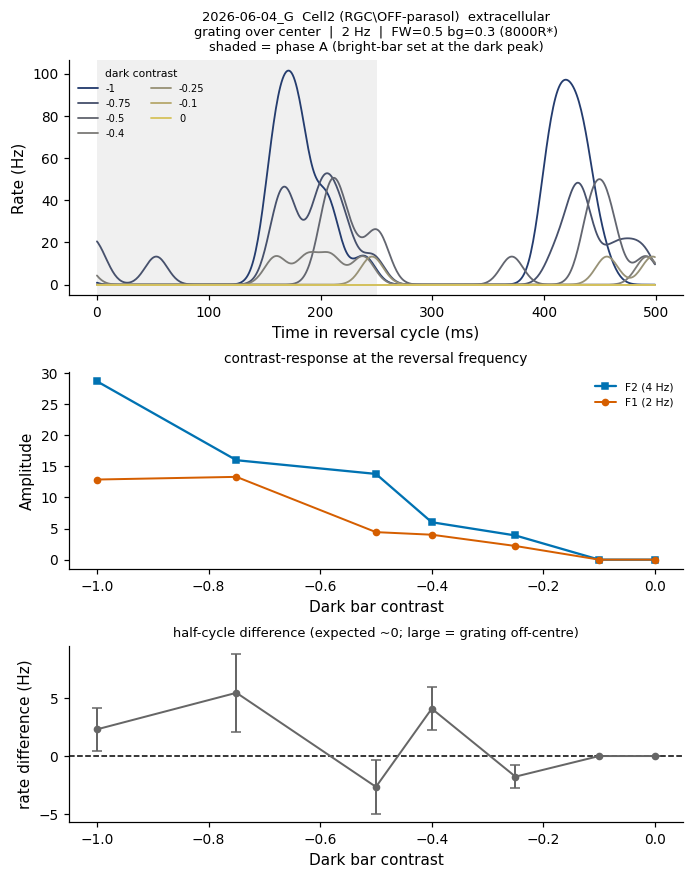

In [13]:
# Change CELL to inspect a different one. Each condition is analyzed and
# plotted in turn, and the records are returned for further poking.
CELL = '2026-06-04_G/Cell2'

cell_records = crg.inspect_cell(CELL, canonical)